In [1]:
import numpy as np
import cv2 as cv
import os
import glob
import sys
sys.path.append("../")
from PIL import Image
from matplotlib import pyplot as plt
from map.quadtree import FixedQuadTree

In [2]:
def get_image(root_dir):
    classes = sorted(os.listdir(root_dir))  # Get class directories
    image_paths = []
    for cls_name in classes:
        cls_dir = os.path.join(root_dir, cls_name)
        for img_path in glob.glob(os.path.join(cls_dir, "*.JPEG")):  # Adjust extension if needed
            image_paths.append(img_path)
    return image_paths

def patchify(img, fixed_length=196, patch_size=16, smooth_factor=5, canny=[50, 100]):
    grey_img = cv.GaussianBlur(img, (smooth_factor, smooth_factor), 0)
    edges = cv.Canny(grey_img, canny[0], canny[1])
    qdt = FixedQuadTree(domain=edges, fixed_length=fixed_length)
    seq_img, seq_size, seq_pos = qdt.serialize(img, size=(patch_size,patch_size,3))
    seq_size = np.asarray(seq_size)
    seq_img = np.asarray(seq_img)
    seq_img = np.reshape(seq_img, [patch_size*patch_size, -1, 3])
    return seq_img, seq_size, seq_pos, qdt, grey_img, edges

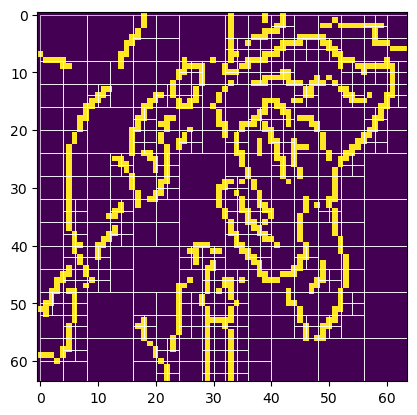

433


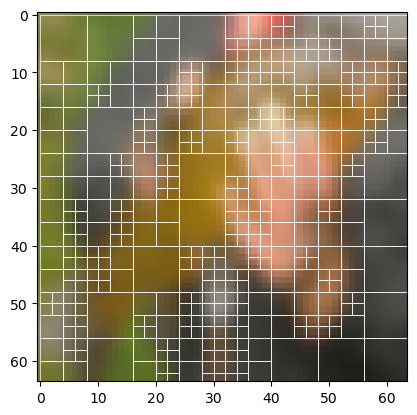

433


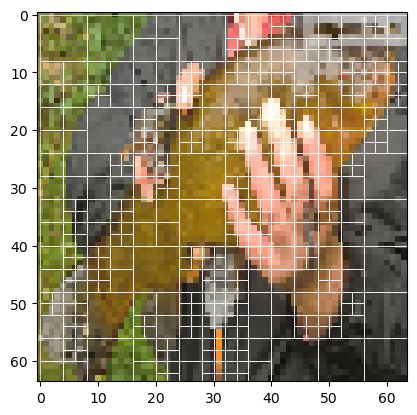

2.3268482490272375


In [7]:
img_path = get_image(root_dir = '/Volumes/data/dataset/imagenet/train')

res = 64
idx = 2
# for idx in range(len(img_path)):
img_path = img_path[idx]
# Open image
image = Image.open(img_path).convert("RGB")
image = np.array(image)
image = cv.resize(image, dsize=[res,res])
seq_img, seq_size, seq_pos, qdt, grey_img, edges= patchify(image, fixed_length=514, patch_size=4, smooth_factor=9, canny=[50, 100])

fig, ax = plt.subplots()
ax.imshow(edges)
qdt.draw(ax=ax)
plt.show()
print(qdt.count_patches())
plt.close()

fig, ax = plt.subplots()
ax.imshow(grey_img)
qdt.draw(ax=ax)
plt.show()
print(qdt.count_patches())
plt.close()

fig, ax = plt.subplots()
ax.imshow(image)
qdt.draw(ax=ax)
plt.show()
print(np.sum(seq_size)/len(seq_pos))
plt.close()

In [8]:
sum(seq_size)

1196

In [9]:
seq_size

array([4, 4, 4, 2, 2, 2, 2, 8, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 8,
       4, 2, 2, 2, 2, 4, 2, 2, 2, 2, 4, 2, 2, 2, 2, 4, 2, 2, 2, 2, 2, 2,
       2, 2, 4, 4, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4,
       2, 2, 2, 2, 4, 2, 2, 2, 2, 2, 2, 2, 2, 4, 2, 2, 2, 2, 4, 4, 2, 2,
       2, 2, 4, 2, 2, 2, 2, 4, 2, 2, 2, 2, 4, 2, 2, 2, 2, 8, 4, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4, 8, 2, 2, 2, 2, 4, 2, 2, 2,
       2, 4, 8, 2, 2, 2, 2, 4, 2, 2, 2, 2, 4, 4, 2, 2, 2, 2, 4, 4, 8, 8,
       2, 2, 2, 2, 4, 4, 2, 2, 2, 2, 8, 2, 2, 2, 2, 4, 4, 2, 2, 2, 2, 4,
       4, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       4, 4, 4, 4, 2, 2, 2, 2, 4, 4, 4, 8, 4, 4, 2, 2, 2, 2, 4, 8, 4, 4,
       4, 4, 4, 4, 4, 2, 2, 2, 2, 4, 4, 4, 4, 8, 4, 2, 2, 2, 2, 4, 2, 2,
       2, 2, 8, 2, 2, 2, 2, 4, 2, 2, 2, 2, 4, 2, 2, 2, 2, 4, 4, 4, 4, 4,
       4, 4, 2, 2, 2, 2, 4, 4, 4, 8, 8, 4, 2, 2, 2, 2, 4, 4, 2, 2, 2, 2,
       4, 2, 2, 2, 2, 4, 4, 4, 4, 4, 8, 2, 2, 2, 2,